In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
import scipy.stats as ss
from pandas.api.types import CategoricalDtype
from dython.nominal import associations
from scipy.stats import chi2_contingency
from scipy.stats import f_oneway
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import scale
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

<h1>Preprocesamiento<h1>

In [2]:
df_original = pd.read_csv('train.csv')
df_prepocesado = df_original.copy()
df = df_original.copy()

In [3]:
df_original.head()

,Patient_ID,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer,HeartDisease
0,Patient_118020,45.61,Yes,No,No,0.0,0.0,No,Male,35-39,White,No,Yes,Good,360 min,No,No,No,No
1,Patient_196414,37.59,Yes,No,No,7.0,20.0,No,Female,30-34,Hispanic,No,Yes,Very good,480 min,No,No,No,No
2,Patient_107743,19.37,Yes,No,No,0.0,0.0,No,Female,50-54,White,No,Yes,Good,2 hrs,No,No,No,No
3,Patient_28303,48.42,No,No,No,30.0,15.0,No,Female,30-34,White,No,Yes,Fair,8 hrs,No,No,No,No
4,Patient_118489,27.12,No,No,No,0.0,5.0,No,Male,65-69,White,No,Yes,Very good,360 min,Yes,No,No,No


In [4]:
df_original.describe()

,BMI,PhysicalHealth,MentalHealth
count,223856.000000,223856.000000,223856.000000
mean,28.319006,3.365561,3.887763
std,6.351305,7.934696,7.948452
min,12.020000,0.000000,0.000000
25%,24.030000,0.000000,0.000000
50%,27.320000,0.000000,0.000000
75%,31.400000,2.000000,3.000000
max,94.850000,30.000000,30.000000


Reemplazar razas por numeros

In [5]:
# races = {'White': 0,
#          'Hispanic': 1,
#          'Black': 2,
#          'Asian': 3,
#          'Other': 4,
#          'American Indian/Alaskan Native': 5}

# def replace_races_with_number(race):
#     return races.get(race, race)

# df_prepocesado['Race'] = df_prepocesado['Race'].apply(replace_races_with_number)


Reemplazar sexo por numeros

In [6]:
# sexos = {'Male': 1,
#          'Female': 0,}

# def replace_sex_with_number(sex):
#     return sexos.get(sex, sex)

# df_prepocesado['Sex'] = df_prepocesado['Sex'].apply(replace_sex_with_number)

Eliminar el id del dataset

In [7]:
df_prepocesado = df_prepocesado.drop('Patient_ID', axis=1)

Reemplazar GenHealth por numeros

In [8]:
# df_prepocesado['GenHealth'].mask(df_prepocesado['GenHealth'] == 'Good', 4, inplace=True)
# df_prepocesado['GenHealth'].mask(df_prepocesado['GenHealth'] == 'Very good', 3, inplace=True)
# df_prepocesado['GenHealth'].mask(df_prepocesado['GenHealth'] == 'Excellent', 2, inplace=True)
# df_prepocesado['GenHealth'].mask(df_prepocesado['GenHealth'] == 'Fair', 1, inplace=True)
# df_prepocesado['GenHealth'].mask(df_prepocesado['GenHealth'] == 'Poor', 0, inplace=True)

Reemplazar columnas de Yes or no

In [9]:
columnas_categoricas = [ 'PhysicalActivity',
                          'DiffWalking',

                          'Asthma',
                          'KidneyDisease',
                          'SkinCancer',
                          'HeartDisease',
                          'AlcoholDrinking',
                          'Stroke',
                          'Smoking',

                          ]


# for columna in columnas_categoricas:

#     df_prepocesado[columna] = df_prepocesado[columna].map({'Yes': 1, 'No': 0})


In [10]:
df_prepocesado['SleepTime'] = df_prepocesado['SleepTime'].astype(str)
df_prepocesado["SleepTime"] = df_prepocesado['SleepTime'].str.replace(' hrs', '')

def conversion_horas(value):
  if 'min' in value:
    minutos = int(value.replace(' min', ''))
    horas = minutos / 60
    return horas
  else:
    return value

df_prepocesado['SleepTime'] = df_prepocesado["SleepTime"].apply(conversion_horas)
df_prepocesado['SleepTime'] = df_prepocesado['SleepTime'].astype(float)
df_prepocesado['SleepTime'] = df_prepocesado['SleepTime'] / 24
df_prepocesado.head(15)
df_original

,Patient_ID,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer,HeartDisease
0,Patient_118020,45.61,Yes,No,No,0.0,0.0,No,Male,35-39,White,No,Yes,Good,360 min,No,No,No,No
1,Patient_196414,37.59,Yes,No,No,7.0,20.0,No,Female,30-34,Hispanic,No,Yes,Very good,480 min,No,No,No,No
2,Patient_107743,19.37,Yes,No,No,0.0,0.0,No,Female,50-54,White,No,Yes,Good,2 hrs,No,No,No,No
3,Patient_28303,48.42,No,No,No,30.0,15.0,No,Female,30-34,White,No,Yes,Fair,8 hrs,No,No,No,No
4,Patient_118489,27.12,No,No,No,0.0,5.0,No,Male,65-69,White,No,Yes,Very good,360 min,Yes,No,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
223851,Patient_153509,36.50,Yes,No,No,0.0,0.0,Yes,Male,70-74,White,Yes,Yes,Good,8 hrs,No,No,No,Yes
223852,Patient_48901,30.81,No,No,Yes,0.0,0.0,No,Male,45-49,Black,Yes,Yes,Good,480 min,Yes,Yes,No,No
223853,Patient_305860,25.12,Yes,No,No,0.0,0.0,Yes,Male,70-74,Black,No,Yes,Good,6 hrs,No,No,No,No
223854,Patient_252244,31.47,No,No,No,0.0,0.0,No,Female,60-64,White,No,Yes,Good,9 hrs,No,No,No,No


Escalar los datos numerico y categoricos


In [11]:
scaler = StandardScaler()
numeric_features = ['BMI', 'PhysicalHealth', 'MentalHealth', 'SleepTime']
df_prepocesado[numeric_features] = scaler.fit_transform(df_prepocesado[numeric_features])

In [12]:
enc = OrdinalEncoder()
categorical_features = [ 'Smoking', 'AlcoholDrinking', 'Stroke',
        'DiffWalking', 'Sex', 'AgeCategory',
       'Race', 'Diabetic', 'PhysicalActivity', 'GenHealth',
       'Asthma', 'KidneyDisease', 'SkinCancer', 'HeartDisease']
enc.fit(df_prepocesado[categorical_features])
df_prepocesado[categorical_features] = enc.transform(df_prepocesado[categorical_features])

Revisar si hay datos vacios 

In [13]:
df_prepocesado[df_prepocesado.isnull().any(axis=1)]

,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer,HeartDisease


<h1>Analisis demografico<h1>

<Axes: xlabel='Count', ylabel='AgeCategory'>

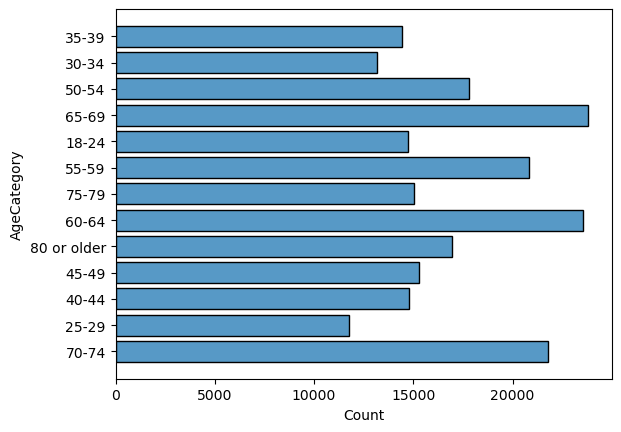

In [14]:
sns.histplot(data=df, y="AgeCategory", shrink=.8)


<Axes: xlabel='Count', ylabel='Sex'>

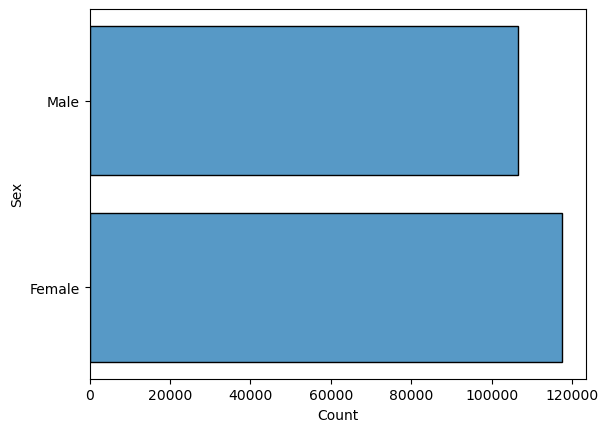

In [15]:
sns.histplot(data=df, y="Sex", shrink=.8)


<Axes: xlabel='Count', ylabel='Race'>

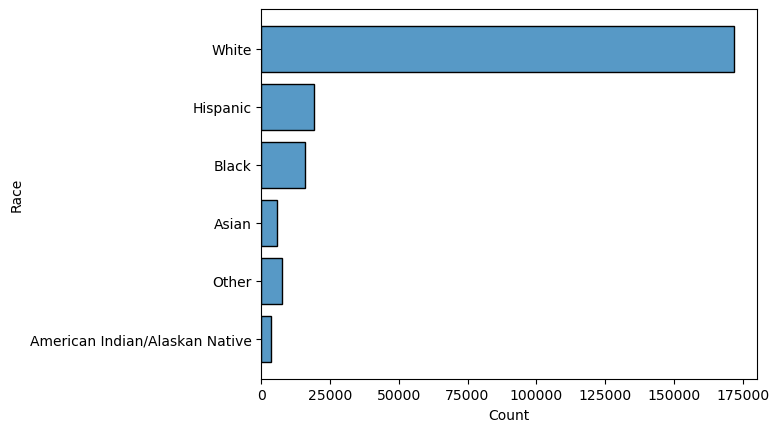

In [16]:
sns.histplot(data=df, y="Race", shrink=.8)


In [17]:
print(sorted(df['AgeCategory'].unique()))

['18-24', '25-29', '30-34', '35-39', '40-44', '45-49', '50-54', '55-59', '60-64', '65-69', '70-74', '75-79', '80 or older']


In [18]:
df['AgeCategory'] = pd.Categorical(df['AgeCategory'],
['18-24', '25-29', '30-34', '35-39', '40-44', '45-49', '50-54', '55-59', '60-64', '65-69', '70-74', '75-79', '80 or older']
)

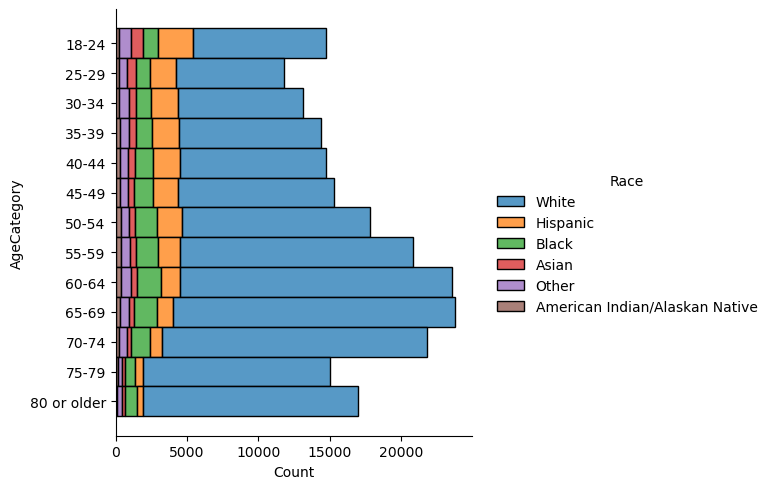

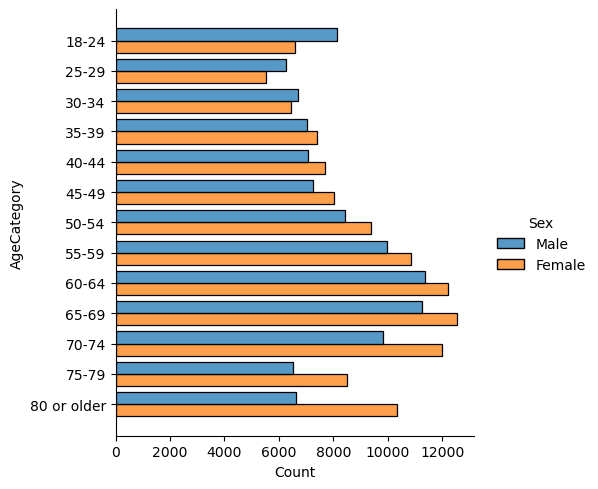

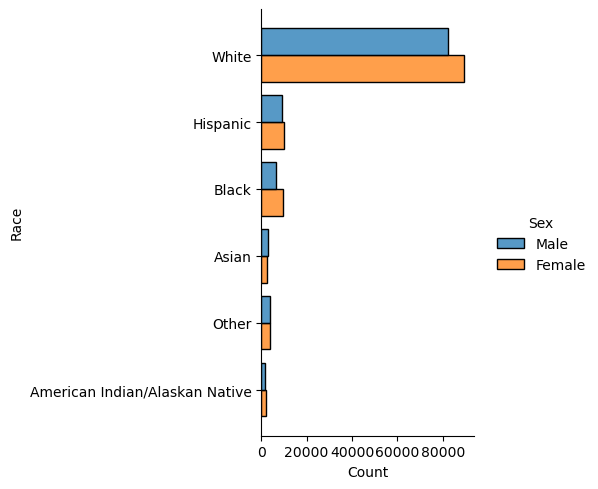

In [19]:

sns.displot(df, y="AgeCategory",hue='Race', multiple='stack'
)
sns.displot(df, y="AgeCategory",hue='Sex',  multiple="dodge", shrink=.8,
            )
sns.displot(df, y="Race",hue='Sex', multiple="dodge", shrink=.8,)

In [20]:
df[['AgeCategory', 'Sex', 'Race']].mode()

,AgeCategory,Sex,Race
0,65-69,Female,White


<h3>- Identificar las características demográficas más comunes entre los pacientes.</h3>
R: La mayoria son mujeres blancas de 65-69 años

<h1>Análisis de Actividad Física y Estado de Salud</h1>

<h3>- Investigar la relación entre la actividad física y el estado de salud de los pacientes.</h3>


In [21]:
category_values = ['Good', 'Very good',  'Excellent', 'Fair','Poor']
category_order = CategoricalDtype(category_values, ordered=True)
df['GenHealth']= df['GenHealth'].astype(category_order)


<Axes: xlabel='PhysicalActivity', ylabel='Count'>

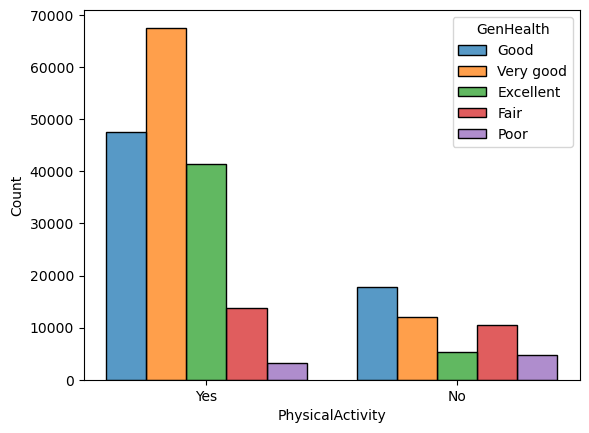

In [22]:
sns.histplot(df, x="PhysicalActivity",hue='GenHealth', multiple="dodge", shrink=.8)



In [23]:
# importing the required function
def get_chi2_result(column1, column2):
    cross_tab=pd.crosstab(index=df[column1],columns=df[column2])
    print(cross_tab)
    chi_sq_result = chi2_contingency(cross_tab,)
    p, x = chi_sq_result[1], "reject" if chi_sq_result[1] < 0.05 else "accept"

    print(f"The p-value is {chi_sq_result[1]} and hence we {x} the null Hpothesis with {chi_sq_result[2]} degrees of freedom")
    print(chi_sq_result[0])

# get_chi2_result('PhysicalActivity', 'GenHealth')

In [24]:
# https://stackoverflow.com/questions/46498455/categorical-features-correlation/46498792#46498792
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(df[x],df[y])
    chi2 = ss.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2/n
    r,k = confusion_matrix.shape
    phi2corr = max(0, phi2-((k-1)*(r-1))/(n-1))
    rcorr = r-((r-1)**2)/(n-1)
    kcorr = k-((k-1)**2)/(n-1)
    res = np.sqrt(phi2corr/min((kcorr-1),(rcorr-1)))
    print('La correlacion entre ', x, 'y ', y, 'es: ' , res)


cramers_v('PhysicalActivity', 'GenHealth')


La correlacion entre  PhysicalActivity y  GenHealth es:  0.29339857433860556


R: Entre mayor actividad fisica es mejor su estado de salud

<h3>Determinar cómo la actividad física y su dificultad para caminar (DiffWalking) se
correlaciona con indicadores de salud como el índice de masa corporal (BMI), la salud física y
mental, y la prevalencia de enfermedades crónicas.
</h3>

Correlacion con el indice de masa corporal BMI

In [25]:
df['SkinCancer'].value_counts()

SkinCancer
No     203000
Yes     20856
Name: count, dtype: int64

In [26]:
df.head()

,Patient_ID,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer,HeartDisease
0,Patient_118020,45.61,Yes,No,No,0.0,0.0,No,Male,35-39,White,No,Yes,Good,360 min,No,No,No,No
1,Patient_196414,37.59,Yes,No,No,7.0,20.0,No,Female,30-34,Hispanic,No,Yes,Very good,480 min,No,No,No,No
2,Patient_107743,19.37,Yes,No,No,0.0,0.0,No,Female,50-54,White,No,Yes,Good,2 hrs,No,No,No,No
3,Patient_28303,48.42,No,No,No,30.0,15.0,No,Female,30-34,White,No,Yes,Fair,8 hrs,No,No,No,No
4,Patient_118489,27.12,No,No,No,0.0,5.0,No,Male,65-69,White,No,Yes,Very good,360 min,Yes,No,No,No


In [27]:
def get_anova(col_categorica, col_continua):

    # Running the one-way anova test between CarPrice and FuelTypes
    # Assumption(H0) is that FuelType and CarPrices are NOT correlated

    CategoryGroupLists=df.groupby(col_categorica)[col_continua].apply(list)

    # Performing the ANOVA test
    # We accept the Assumption(H0) only when P-Value &gt> 0.05
    AnovaResults = f_oneway(*CategoryGroupLists)
    print('P-Value for Anova is: ', AnovaResults[1])


La correlacion entre  PhysicalActivity y  BMI es:  0.19336706448400778
La correlacion entre  DiffWalking y  BMI es:  0.23477670858784697


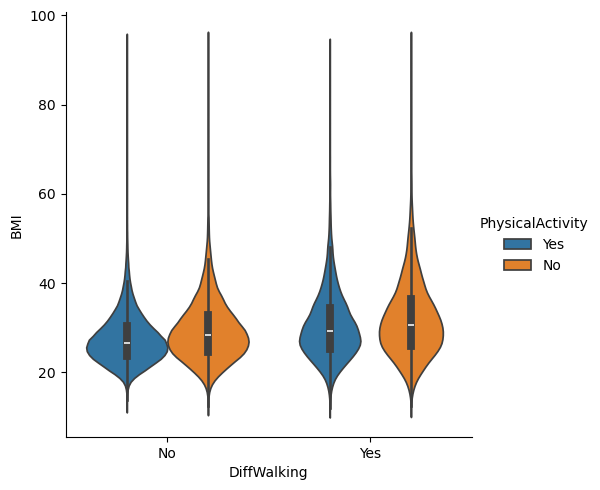

In [28]:
cramers_v('PhysicalActivity', 'BMI')
cramers_v('DiffWalking', 'BMI')
sns.catplot(df, hue="PhysicalActivity",x='DiffWalking', y='BMI', kind='violin')

La correlacion entre  PhysicalActivity y  PhysicalHealth es:  0.2307853040971636
La correlacion entre  DiffWalking y  PhysicalHealth es:  0.433347745651503


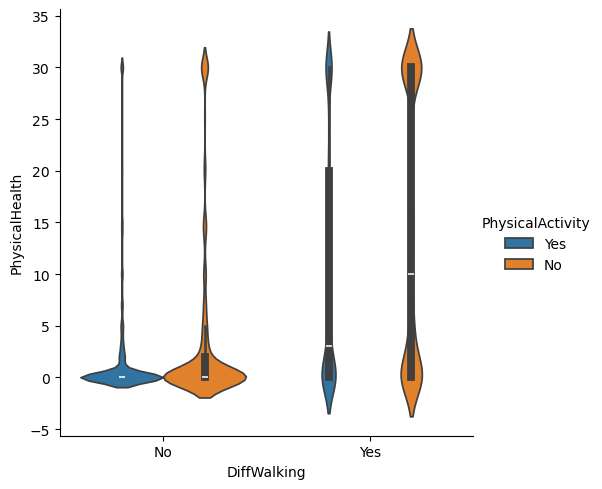

In [29]:
cramers_v('PhysicalActivity', 'PhysicalHealth')
cramers_v('DiffWalking', 'PhysicalHealth')
sns.catplot(df, hue="PhysicalActivity",x='DiffWalking', y='PhysicalHealth', kind='violin')


La correlacion entre  PhysicalActivity y  MentalHealth es:  0.1138670370968151
La correlacion entre  DiffWalking y  MentalHealth es:  0.15474866649873337


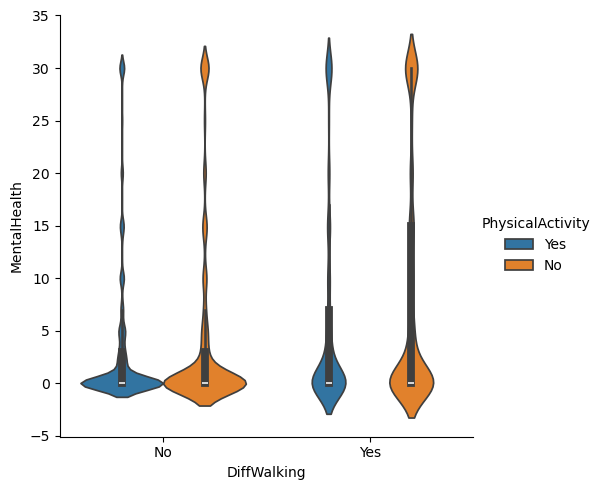

In [30]:
cramers_v('PhysicalActivity', 'MentalHealth')
cramers_v('DiffWalking', 'MentalHealth')
sns.catplot(df, hue="PhysicalActivity",x='DiffWalking', y='MentalHealth', kind='violin')

La correlacion entre  PhysicalActivity y  Asthma es:  0.04054079375126068
La correlacion entre  DiffWalking y  Asthma es:  0.10372423230749543


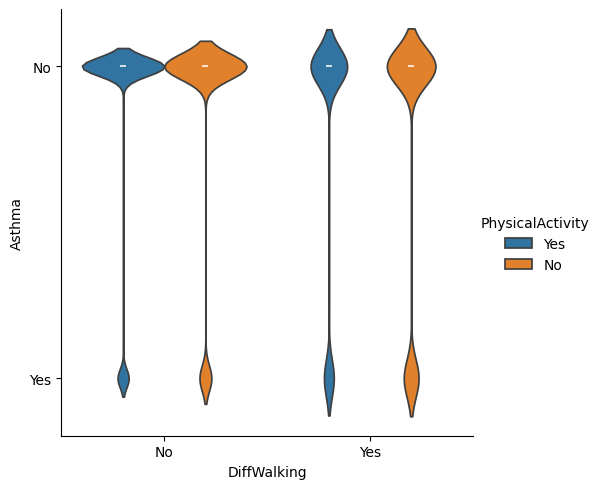

In [31]:
cramers_v('PhysicalActivity', 'Asthma')
cramers_v('DiffWalking', 'Asthma')
sns.catplot(df, hue="PhysicalActivity",x='DiffWalking', y='Asthma', kind='violin')

La correlacion entre  PhysicalActivity y  KidneyDisease es:  0.08115576215380074
La correlacion entre  DiffWalking y  KidneyDisease es:  0.15047285824946655


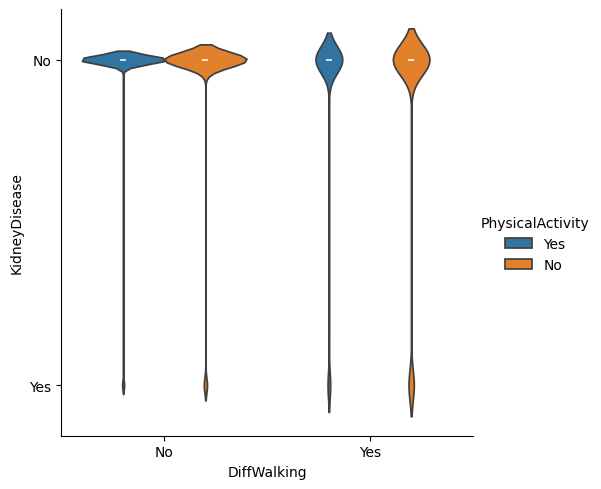

In [32]:
cramers_v('PhysicalActivity', 'KidneyDisease')
cramers_v('DiffWalking', 'KidneyDisease')
sns.catplot(df, hue="PhysicalActivity",x='DiffWalking', y='KidneyDisease', kind='violin')

La correlacion entre  PhysicalActivity y  SkinCancer es:  0.0
La correlacion entre  DiffWalking y  SkinCancer es:  0.06401495174349252


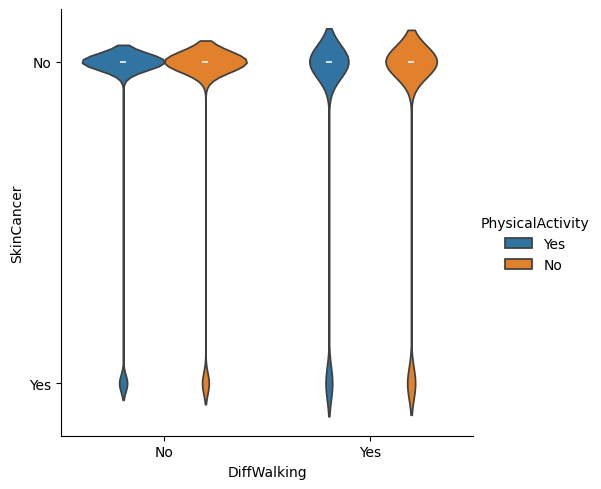

In [33]:
cramers_v('PhysicalActivity', 'SkinCancer')
cramers_v('DiffWalking', 'SkinCancer')
sns.catplot(df, hue="PhysicalActivity",x='DiffWalking', y='SkinCancer', kind='violin')

La correlacion entre  PhysicalActivity y  HeartDisease es:  0.09988254701515828
La correlacion entre  DiffWalking y  HeartDisease es:  0.20039596276147312


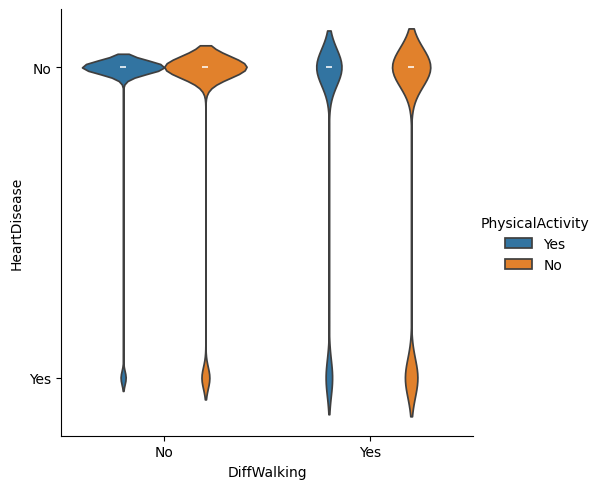

In [34]:
cramers_v('PhysicalActivity', 'HeartDisease')
cramers_v('DiffWalking', 'HeartDisease')
sns.catplot(df, hue="PhysicalActivity",x='DiffWalking', y='HeartDisease', kind='violin')

La correlacion entre  PhysicalActivity y  Diabetic es:  0.14308010212906763
La correlacion entre  DiffWalking y  Diabetic es:  0.21820482770288605


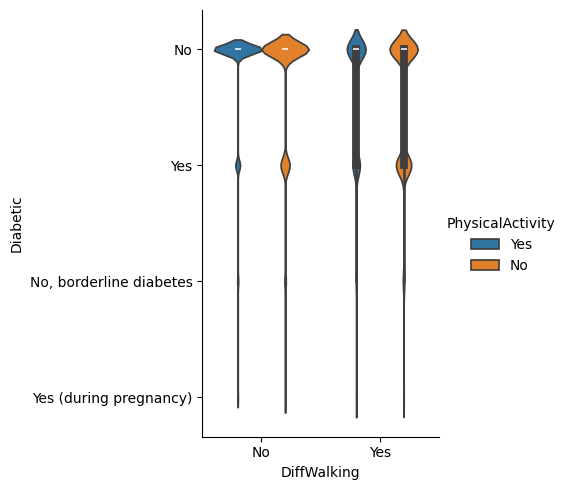

In [35]:
cramers_v('PhysicalActivity', 'Diabetic')
cramers_v('DiffWalking', 'Diabetic')
sns.catplot(df, hue="PhysicalActivity",x='DiffWalking', y='Diabetic', kind='violin')

c:\Users\Tauro\anaconda3\Lib\site-packages\dython\nominal.py:736: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  inf_nan.loc[columns[i], columns[j]] = _inf_nan_str(ij)
c:\Users\Tauro\anaconda3\Lib\site-packages\dython\nominal.py:737: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  inf_nan.loc[columns[j], columns[i]] = _inf_nan_str(ji)


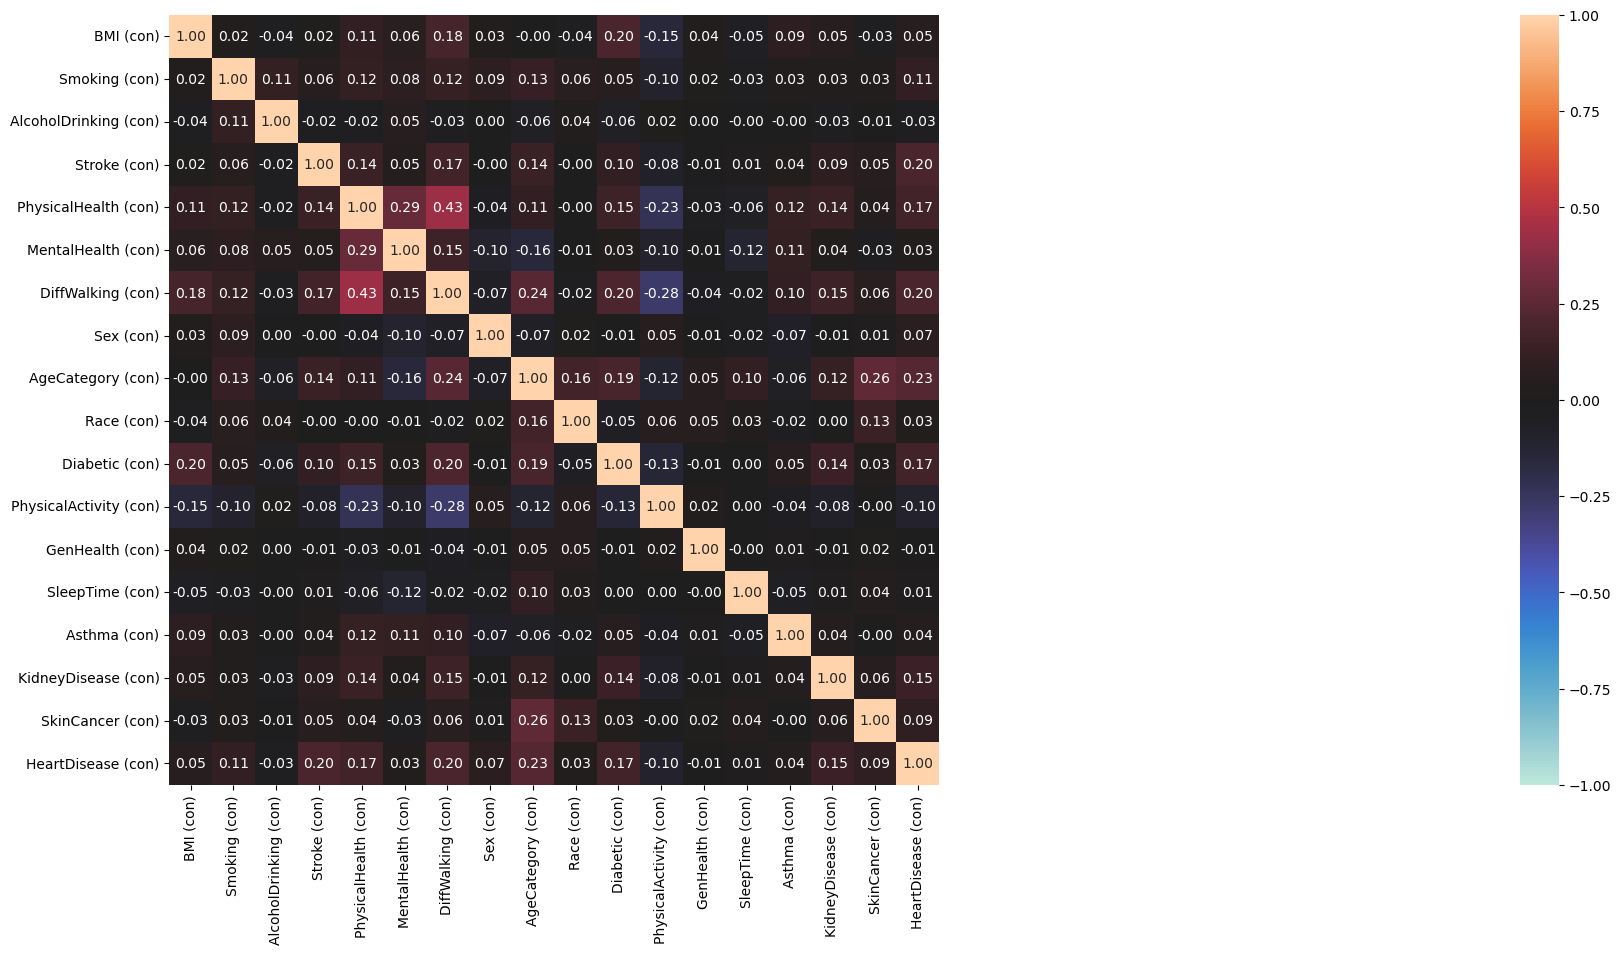

{'corr':                         BMI (con)  Smoking (con)  AlcoholDrinking (con)  \
 BMI (con)                1.000000       0.023871              -0.038314   
 Smoking (con)            0.023871       1.000000               0.112849   
 AlcoholDrinking (con)   -0.038314       0.112849               1.000000   
 Stroke (con)             0.018832       0.061279              -0.018671   
 PhysicalHealth (con)     0.108828       0.115456              -0.016254   
 MentalHealth (con)       0.064941       0.084935               0.053233   
 DiffWalking (con)        0.181616       0.121230              -0.032809   
 Sex (con)                0.027180       0.086538               0.004202   
 AgeCategory (con)       -0.004796       0.127959              -0.061437   
 Race (con)              -0.038117       0.064730               0.035516   
 Diabetic (con)           0.202953       0.054058              -0.058401   
 PhysicalActivity (con)  -0.152546      -0.097665               0.015837   
 Gen

In [36]:
columnas_correlaciones = [ 'PhysicalActivity',
                          'DiffWalking',
                          'BMI',
                          'PhysicalHealth',
                          'MentalHealth',
                          'Asthma',
                          'KidneyDisease',
                          'SkinCancer',
                          'HeartDisease',
                          'Diabetic',
                          ]

df_prepocesado2 = df_prepocesado
associations(df_prepocesado2,figsize=(150, 10),
            #  nominal_columns='all',
            #  numerical_columns=['BMI, PhysicalHealth, MentalHealth'],
             mark_columns=True)

R: Se encontro que hay una correlacion entre el Diffwalking, y la diabetes y las enfermedades del corazon

<h3>Explorar cualquier asociación entre la actividad física y la presencia de condiciones crónicas
como enfermedades cardíacas o diabetes en el conjunto de datos.</h3>

La correlacion entre  PhysicalActivity y  Diabetic es:  0.14308010212906763


<Axes: xlabel='PhysicalActivity', ylabel='Count'>

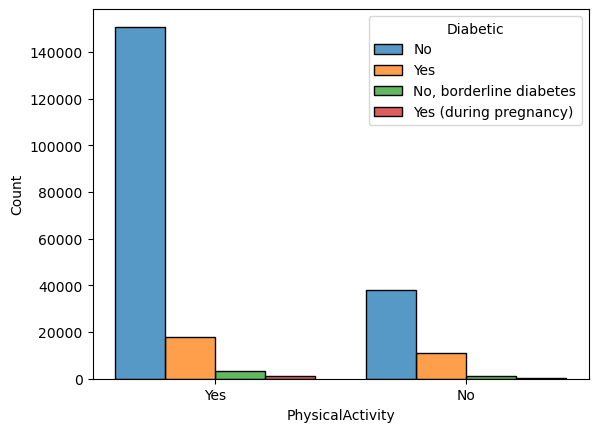

In [37]:
cramers_v('PhysicalActivity', 'Diabetic')
sns.histplot(df, x="PhysicalActivity",hue='Diabetic', multiple="dodge", shrink=.8)

La correlacion entre  PhysicalActivity y  HeartDisease es:  0.09988254701515828


<Axes: xlabel='PhysicalActivity', ylabel='Count'>

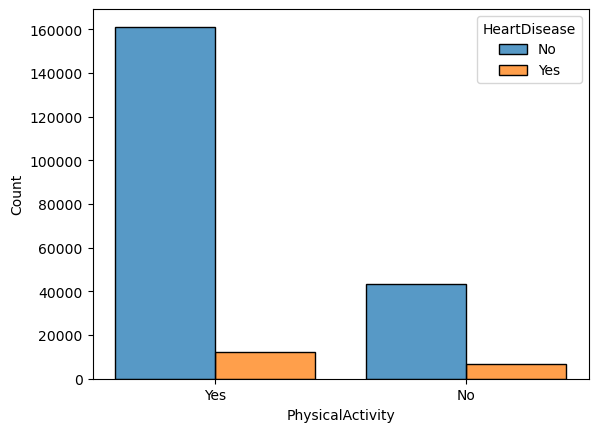

In [38]:
cramers_v('PhysicalActivity', 'HeartDisease')
sns.histplot(df, x="PhysicalActivity",hue='HeartDisease',multiple="dodge", shrink=.8)

La correlacion entre  PhysicalActivity y  SkinCancer es:  0.0


<Axes: xlabel='PhysicalActivity', ylabel='Count'>

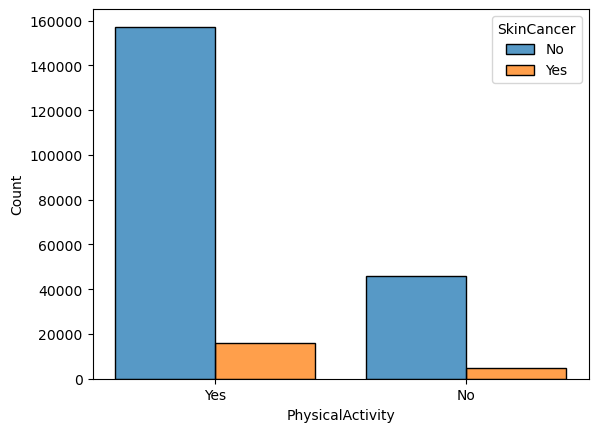

In [39]:
cramers_v('PhysicalActivity', 'SkinCancer')
sns.histplot(df, x="PhysicalActivity",hue='SkinCancer',multiple="dodge", shrink=.8)

La correlacion entre  PhysicalActivity y  KidneyDisease es:  0.08115576215380074


<Axes: xlabel='PhysicalActivity', ylabel='Count'>

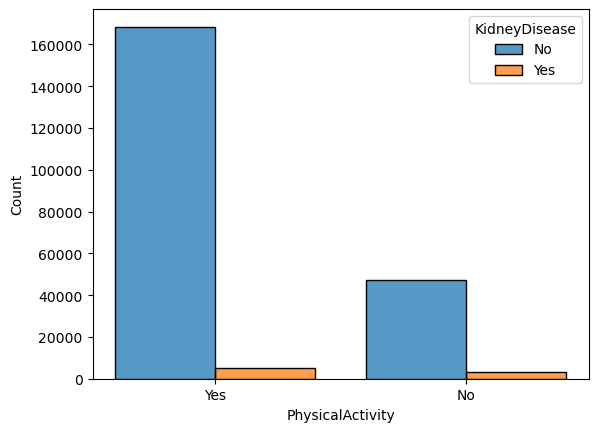

In [40]:
cramers_v('PhysicalActivity', 'KidneyDisease')
sns.histplot(df, x="PhysicalActivity",hue='KidneyDisease',multiple="dodge", shrink=.8)

La correlacion entre  PhysicalActivity y  Asthma es:  0.04054079375126068


<Axes: xlabel='PhysicalActivity', ylabel='Count'>

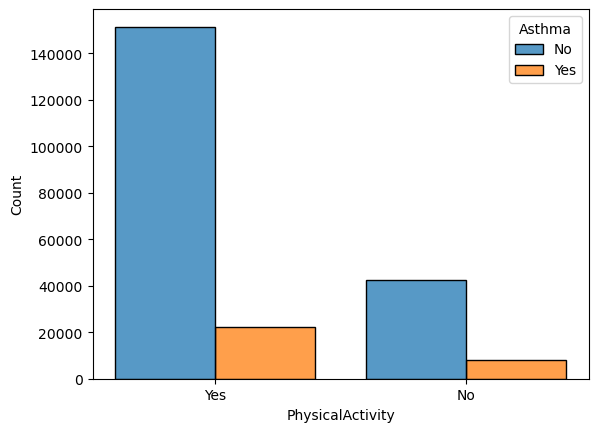

In [41]:
cramers_v('PhysicalActivity', 'Asthma')
sns.histplot(df, x="PhysicalActivity",hue='Asthma',multiple="dodge", shrink=.8)


R: Entre mayor actividad Fisica, menor probabilidad hay de obtener enfermedades cronicas

<h1>Modelo ML</h1>

In [42]:
y = df_prepocesado['HeartDisease']
X = df_prepocesado.drop(['HeartDisease'], axis=1)
X

,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,2.722438,1.0,0.0,0.0,-0.424158,-0.489123,0.0,1.0,3.0,5.0,0.0,1.0,2.0,-0.762855,0.0,0.0,0.0
1,1.459702,1.0,0.0,0.0,0.458045,2.027096,0.0,0.0,2.0,3.0,0.0,1.0,4.0,0.627511,0.0,0.0,0.0
2,-1.409006,1.0,0.0,0.0,-0.424158,-0.489123,0.0,0.0,6.0,5.0,0.0,1.0,2.0,-3.543588,0.0,0.0,0.0
3,3.164867,0.0,0.0,0.0,3.356713,1.398041,0.0,0.0,2.0,5.0,0.0,1.0,1.0,0.627511,0.0,0.0,0.0
4,-0.188781,0.0,0.0,0.0,-0.424158,0.139932,0.0,1.0,9.0,5.0,0.0,1.0,4.0,-0.762855,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
223851,1.288084,1.0,0.0,0.0,-0.424158,-0.489123,1.0,1.0,10.0,5.0,2.0,1.0,2.0,0.627511,0.0,0.0,0.0
223852,0.392203,0.0,0.0,1.0,-0.424158,-0.489123,0.0,1.0,5.0,2.0,2.0,1.0,2.0,0.627511,1.0,1.0,0.0
223853,-0.503678,1.0,0.0,0.0,-0.424158,-0.489123,1.0,1.0,10.0,2.0,0.0,1.0,2.0,-0.762855,0.0,0.0,0.0
223854,0.496119,0.0,0.0,0.0,-0.424158,-0.489123,0.0,0.0,8.0,5.0,0.0,1.0,2.0,1.322695,0.0,0.0,0.0


In [43]:


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [44]:


# clf_svm = SVC(random_state = 42,kernel='linear', C=0.1)
# clf_svm.fit(X_train, y_train)


In [45]:
# calculate overall accuracy
from sklearn.model_selection import GridSearchCV

# defining parameter range
param_grid = {'C': [0.1, 1, 10, 100, 1000],
              'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
              'kernel': ['linear']}

grid = GridSearchCV(SVC(), param_grid, refit = True, verbose = 3,n_jobs=-1)

# fitting the model for grid search
grid.fit(X_train, y_train)

y_pred = grid.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2%}')

class_names = ['No','Yes']
disp = ConfusionMatrixDisplay.from_estimator(
        grid,
        X_test,
        y_test,
        display_labels=class_names,
        cmap=plt.cm.Blues)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


In [ ]:
df_prepocesado['HeartDisease'].value_counts()

HeartDisease
0.0    204695
1.0     19161
Name: count, dtype: int64

In [ ]:
df_original['HeartDisease'].value_counts()

HeartDisease
No     204695
Yes     19161
Name: count, dtype: int64